In [1]:
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")
import torch
print(f"Torch version: {torch.__version__}")
import cv2
import numpy as np
from ultralytics import YOLO    
import os
from PIL import Image
from torchvision import transforms
from IPython.display import display, clear_output 
from collections import defaultdict



Ultralytics version: 8.4.23
Torch version: 2.10.0+cu128


In [2]:

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

device = "cuda" if torch.cuda.is_available() else "cpu"
x = torch.rand(10000,10000).to(device)
print(x.device)

2.10.0+cu128
12.8
True
NVIDIA GeForce RTX 5060 Laptop GPU
cuda:0


In [3]:
!nvidia-smi

Tue Mar 17 21:38:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   50C    P2             15W /   60W |     507MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
model = YOLO('yolo26n.pt')
video_path = r"data/traffic.mp4"
cap = cv2.VideoCapture(video_path)

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

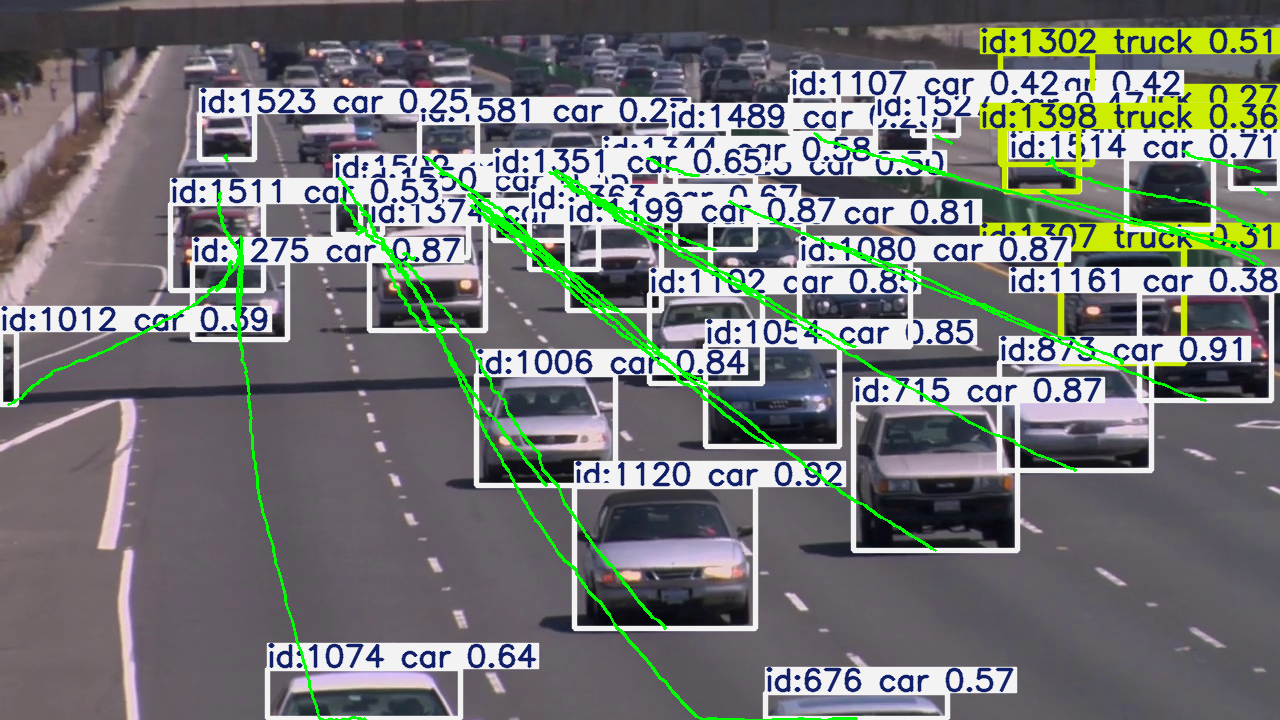

Save Video


In [14]:
import cv2
import numpy as np
from collections import defaultdict
from PIL import Image
from IPython.display import display, clear_output


frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))


fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('trajectory.mp4', fourcc, fps, (frame_width, frame_height))

track_history = defaultdict(lambda: [])

try:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        results = model.track(
            imgsz= 1280,
            source=frame, 
            conf=0.1, 
            persist=True,  
            verbose=False, 
            device=0 if device == 'cuda' else 'cpu'
        )

        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xywh.cpu()
            track_ids = results[0].boxes.id.int().cpu().tolist()
            
            annotated_frame = results[0].plot()

            for box, track_id in zip(boxes, track_ids):
                x, y, w, h = box
                track = track_history[track_id]
                track.append((float(x), float(y + h/2)))  
                
                points = np.array(track).astype(np.int32).reshape((-1, 1, 2))
                cv2.polylines(annotated_frame, [points], isClosed=False, color=(0, 255, 0), thickness=2)

        else:
            annotated_frame = results[0].plot()


        out.write(annotated_frame)
        annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(annotated_frame_rgb)

        clear_output(wait=True)
        display(img)

except KeyboardInterrupt:
    print("Stopped")

finally:
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    print("Save Video")